In [4]:
import pandas as pd

df = pd.read_csv("../data/raw/all_reviews.csv")

df.head()

C:\Users\gabri\AppData\Local\Temp\ipykernel_34312\4239810078.py:3: DtypeWarning: Columns (0: advice, 1: Career Opportunities, 2: Compensation and Benefits, 3: Senior Management, 4: Work/Life Balance) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/all_reviews.csv")


,rating,title,status,pros,cons,advice,Recommend,CEO Approval,Business Outlook,Career Opportunities,Compensation and Benefits,Senior Management,Work/Life Balance,Culture & Values,Diversity & Inclusion,firm_link,date,job,index
0,5.0,Good,"Current Employee, more than 10 years",Knowledge gain of complete project,Financial growth and personal growth,NaN,v,o,v,3,3,3,3,3.0,3.0,Reviews/Baja-Steel-and-Fence-Reviews-E5462645.htm,"Nov 19, 2022",Manager Design,NaN
1,4.0,Good,"Former Employee, less than 1 year","Good work,good work , flexible, support","Good,work, flexible,good support, good team work",NaN,v,o,o,4,4,4,4,4.0,4.0,Reviews/Baja-Steel-and-Fence-Reviews-E5462645.htm,"Jan 29, 2022",Anonymous Employee,NaN
2,4.0,"Supervising the manufacturing the processes, e...","Current Employee, more than 1 year",This company is a best opportunity for me to l...,"Monthly Target work,Maintain production schedu...",NaN,v,o,v,2,3,2,2,2.0,2.0,Reviews/Baja-Steel-and-Fence-Reviews-E5462645.htm,"Aug 12, 2021",Production Engineer,NaN
3,1.0,terrible,"Current Employee, more than 1 year",I wish there were some to list,too many to list here,NaN,x,x,x,1.0,3.0,1.0,3.0,1.0,NaN,https://www.glassdoor.com/Reviews/Calgary-Flam...,"Sep 24, 2020",Senior Account Executive,NaN
4,4.0,"It could be so good, but it isn’t","Current Employee, more than 3 years",Fast Paced. Endless challenges. Inclusive envi...,The biggest perk of the job provides no value ...,NaN,o,o,o,3.0,3.0,3.0,1.0,4.0,5.0,https://www.glassdoor.com/Reviews/Calgary-Flam...,"Mar 25, 2023",Assistant Manager,NaN


In [5]:
df_model = df[[
    'Work/Life Balance',
    'Culture & Values',
    'Career Opportunities',
    'Compensation and Benefits',
    'Senior Management',
    'Recommend'
]].dropna()

In [6]:
from sklearn.ensemble import RandomForestClassifier

X = df_model.drop(columns=['Recommend'])
y = (df_model['Recommend'] == 'v').astype(int)

model = RandomForestClassifier(n_estimators=50)
model.fit(X, y)

importances = model.feature_importances_

In [7]:
features = X.columns

for f, imp in zip(features, importances):
    print(f"{f}: {imp:.3f}")

Work/Life Balance: 0.084
Culture & Values: 0.308
Career Opportunities: 0.210
Compensation and Benefits: 0.034
Senior Management: 0.364


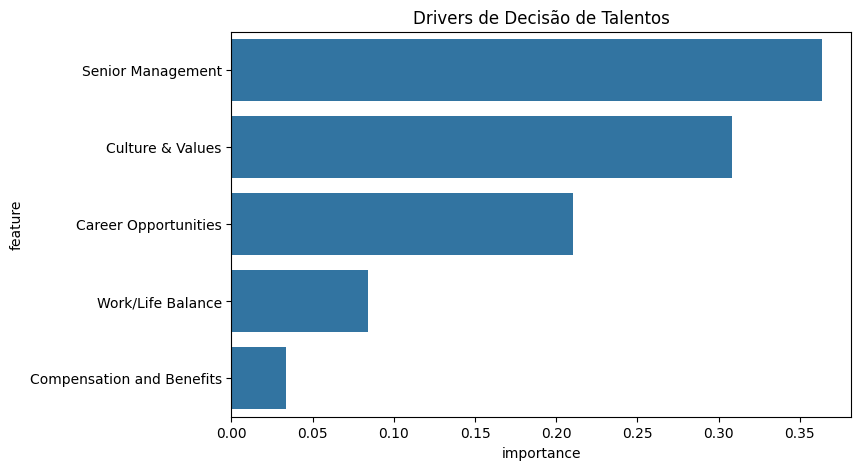

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Drivers de Decisão de Talentos')
plt.show()